# Eample of Getting Data Products
This notebook is an example of getting a day block from the NIST PDR and selecting a single capture, and getting all of the possible data products using [nasctn-sea-visualization](https://github.com/usnistgov/nasctn-sea-visualization/tree/main). 

## Downloading the data from NIST PDR

In [1]:
# takes ~13 seconds
import requests

url = "https://data.nist.gov/od/ds/mds2-4214/Raw%20Data/2024-07-15_GMM.zip"
local_filename = "2024-07-15_GMM.zip"

# Send a GET request to the URL
response = requests.get(url)

# Open a local file in write-binary mode and save the content
with open(local_filename, "wb") as file:
    file.write(response.content)

## Loading the day block using nasctn-sea-visualization

In [2]:
from nasctn_sea_visualization import *

Importing nasctn_sea_visualization.data_models
It took 1.182943 s to import nasctn_sea_visualization.data_models
Importing nasctn_sea_visualization.plotters


It took 2.217793 s to import nasctn_sea_visualization.plotters
It took 3.400736 s to import all of the active modules


In [3]:
day_block_path = "2024-07-15_GMM.zip"
day_block = DayBlock(file_path = day_block_path)

## The DayBlock class has methods to retrieve tables from the raw data.

The most used of these are
```python 
DayBlock.get_day_psd(capture_statistic='mean', save=False, save_type='csv') # valid capture statistics are in psd_statistics, returns a dataframe, putting a path name in save will create a serialized version
DayBlock.get_day_aligned_pfp(capture_statistic='mean', detector='rms', save=False, save_type='csv') # valid capture statistics are in pfp_statistics and detectors are in pfp_detectors,returns a dataframe
DayBlock.get_single(single_selector) # valid single_selector is either a int (0 beinging the first in the day and -1 the last) or a datetime object, returns a data object that needs to be passed to DataProduct()
```

In [4]:
print(day_block.psd_statistics)

['max', 'mean', 'median', '25th_percentile', '75th_percentile', '90th_percentile', '95th_percentile', '99th_percentile', '99.9th_percentile', '99.99th_percentile']


In [5]:
psd = day_block.get_day_psd(capture_statistic='99.9th_percentile', save=False, save_type='csv')
psd.head()

,3.530040e+09,3.530120e+09,3.530200e+09,3.530280e+09,3.530360e+09,3.530440e+09,3.530520e+09,3.530600e+09,3.530680e+09,3.530760e+09,...,3.709240e+09,3.709320e+09,3.709400e+09,3.709480e+09,3.709560e+09,3.709640e+09,3.709720e+09,3.709800e+09,3.709880e+09,3.709960e+09
sweep_timestamp,,,,,,,,,,,,,,,,,,,,,
2024-07-15 00:03:29.486000+00:00,-162.250,-160.875,-160.50,-160.500,-160.500,-160.625,-160.500,-160.500,-160.375,-160.375,...,-121.9375,-121.875,-121.9375,-122.1875,-122.1875,-122.0625,-122.2500,-122.4375,-123.0625,-124.5625
2024-07-15 00:05:17.607000+00:00,-162.125,-160.750,-160.25,-160.250,-160.250,-160.250,-160.375,-160.250,-160.250,-160.125,...,-127.1875,-127.125,-127.1250,-127.3750,-127.5625,-127.8125,-127.8750,-128.0000,-128.5000,-129.8750
2024-07-15 00:07:05.358000+00:00,-162.250,-161.000,-160.50,-160.500,-160.500,-160.500,-160.500,-160.500,-160.500,-160.375,...,-127.9375,-127.875,-127.8750,-127.8750,-127.9375,-128.0000,-128.2500,-128.5000,-129.0000,-130.5000
2024-07-15 00:08:53.052000+00:00,-162.250,-161.000,-160.50,-160.625,-160.625,-160.625,-160.625,-160.500,-160.375,-160.375,...,-120.8750,-120.875,-120.8750,-120.9375,-120.9375,-121.0625,-121.3125,-121.5625,-122.0000,-123.5625
2024-07-15 00:10:40.054000+00:00,-162.250,-160.875,-160.50,-160.500,-160.500,-160.500,-160.500,-160.375,-160.375,-160.375,...,-118.0625,-118.000,-118.0625,-118.0625,-118.1875,-118.2500,-118.3750,-118.4375,-119.1875,-120.6875


In [6]:
print(day_block.pfp_statistics)
print(day_block.pfp_detectors)

['min', 'max', 'mean']
['rms', 'peak']


In [7]:
# The index is a division of 10 ms, x_axis is np.linspace(0,10,560)
pfp = day_block.get_day_aligned_pfp(capture_statistic='max', detector='peak', save=False, save_type='csv')
pfp.head()

,frequency,0,1,2,3,4,5,6,7,8,...,550,551,552,553,554,555,556,557,558,559
datetime,,,,,,,,,,,,,,,,,,,,,
2024-07-15 00:01:41.874000+00:00,3.535000e+09,-88.5625,-88.5000,-87.7500,-88.1250,-88.1875,-87.2500,-88.0000,-87.9375,-87.8125,...,-88.3750,-88.0625,-88.3750,-88.3125,-87.8125,-88.5625,-87.6875,-88.1250,-87.5625,-88.3750
2024-07-15 00:03:29.664000+00:00,3.535000e+09,-87.6250,-88.7500,-87.4375,-88.0625,-87.5000,-87.3125,-85.0625,-88.1250,-87.7500,...,-88.1250,-88.5000,-88.0625,-87.6875,-87.3125,-87.8125,-88.5625,-87.3125,-88.4375,-88.0625
2024-07-15 00:05:17.804000+00:00,3.535000e+09,-88.3125,-88.0625,-88.7500,-88.2500,-87.6250,-87.8125,-87.8125,-87.6875,-88.3750,...,-88.0625,-88.3125,-88.1250,-87.5625,-88.4375,-88.8750,-88.0000,-88.3125,-86.8750,-87.0000
2024-07-15 00:07:05.535000+00:00,3.535000e+09,-88.1250,-87.6250,-87.8125,-88.4375,-88.1250,-88.1875,-87.6875,-88.3750,-88.1250,...,-88.6250,-88.3750,-88.3750,-87.8125,-88.5625,-88.3125,-88.4375,-87.4375,-88.0625,-87.3125
2024-07-15 00:08:53.207000+00:00,3.535000e+09,-88.2500,-88.1250,-88.3125,-87.6875,-88.6250,-88.5000,-87.0000,-87.8750,-87.5000,...,-88.3125,-88.2500,-88.6250,-88.1250,-87.5000,-88.1250,-88.5000,-87.5625,-87.8125,-88.1250


In [8]:
print(len(day_block.timestamps))
print(day_block.timestamps[7100])

14112
2024-07-15 12:03:24.957000+00:00


In [9]:
import pandas as pd #just adding this to the current namesapce

In [10]:
single_data = day_block.get_single(single_selector = pd.to_datetime(day_block.timestamps[7100]))
single_data_product = DataProduct(data=single_data)

## DataProduct
The Dataproduct class has a primary method that allows the retrieval of all data products as x,y data vectors
```python
DataProduct.get_xy_data( channel, data_product, capture_statistic=None, detector=None) 
# channel is ether an int (0-18) or frequency in frequencies
# data_product is pfp,psd,apd or pvt
# capture statistic depends on data_product max and mean work for all of them

In [11]:
print(single_data_product.frequencies)
print(single_data_product.timestamps)

[3535000000.0, 3545000000.0, 3555000000.0, 3565000000.0, 3575000000.0, 3585000000.0, 3595000000.0, 3605000000.0, 3615000000.0, 3625000000.0, 3635000000.0, 3645000000.0, 3655000000.0, 3665000000.0, 3675000000.0, 3685000000.0, 3695000000.0, 3705000000.0]
[Timestamp('2024-07-15 12:00:53.188000+0000', tz='UTC'), Timestamp('2024-07-15 12:00:57.866000+0000', tz='UTC'), Timestamp('2024-07-15 12:01:02.789000+0000', tz='UTC'), Timestamp('2024-07-15 12:01:09.596000+0000', tz='UTC'), Timestamp('2024-07-15 12:01:14.533000+0000', tz='UTC'), Timestamp('2024-07-15 12:01:20.220000+0000', tz='UTC'), Timestamp('2024-07-15 12:01:26.077000+0000', tz='UTC'), Timestamp('2024-07-15 12:01:30.946000+0000', tz='UTC'), Timestamp('2024-07-15 12:01:37.735000+0000', tz='UTC'), Timestamp('2024-07-15 12:01:42.617000+0000', tz='UTC'), Timestamp('2024-07-15 12:01:47.545000+0000', tz='UTC'), Timestamp('2024-07-15 12:01:53.576000+0000', tz='UTC'), Timestamp('2024-07-15 12:01:59.423000+0000', tz='UTC'), Timestamp('2024-07

In [12]:
# so to get pfp for max and rms for 3655 MHz
x,y = single_data_product.get_xy_data( channel=3655000000.0, data_product='pfp', capture_statistic="max", detector="rms") 

In [13]:
import matplotlib.pyplot as plt

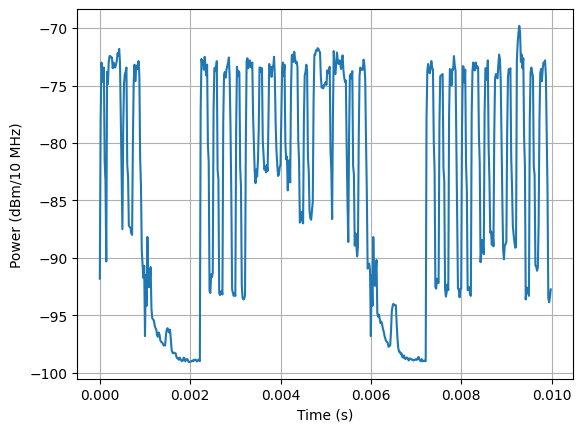

In [14]:
plt.plot(x,y)
plt.xlabel("Time (s)")
plt.ylabel("Power (dBm/10 MHz)")
plt.grid()

In [15]:
# so to get psd for 99.9th_percentile 3655 MHz
x,y = single_data_product.get_xy_data( channel=3655000000.0, data_product='psd', capture_statistic="99.9th_percentile", detector=None) 

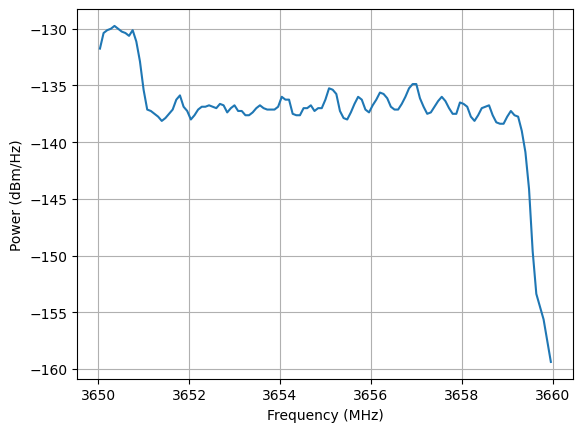

In [16]:
plt.plot(10**-6*(x+3655000000.0),y)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (dBm/Hz)")
plt.grid()

In [17]:
print(single_data_product.pvt_detectors)

['maximum', 'rms']


In [18]:
# so to get pvt for max 3655 MHz
x,y = single_data_product.get_xy_data( channel=3655000000.0, data_product='pvt', capture_statistic=None, detector="maximum") 

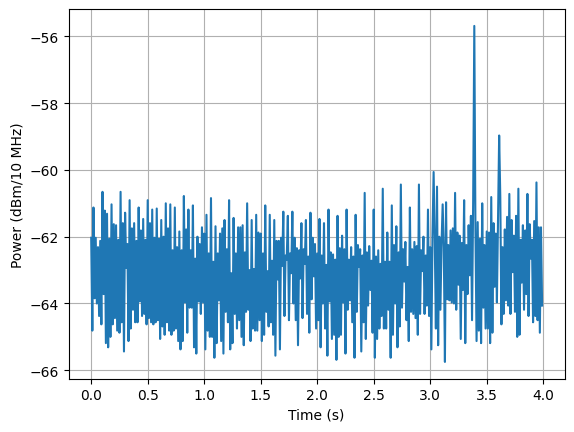

In [19]:
plt.plot(x,y)
plt.xlabel("Time (s)")
plt.ylabel("Power (dBm/10 MHz)")
plt.grid()

# Watermark

In [20]:
%load_ext watermark
%watermark
%watermark --iversions

Last updated: 2026-09-19T10:07:24.639035-06:00

Python implementation: CPython
Python version       : 3.9.23
IPython version      : 8.18.1

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 197 Stepping 2, GenuineIntel
CPU cores   : 16
Architecture: 64bit

dateutil                : 2.9.0.post0
hvplot                  : 0.8.0
json                    : 2.0.9
matplotlib              : 3.9.4
nasctn_sea_visualization: 0.1.6
numpy                   : 1.26.4
pandas                  : 1.5.3
re                      : 2.2.1
requests                : 2.32.5
scipy                   : 1.11.0
sea_ingest              : 1.0.1
seaborn                 : 0.12.0

